# 🚀 AI Startup Advisor — Intelligent Business Strategy System

[![Python](https://img.shields.io/badge/Python-3.10+-blue)](https://python.org)
[![Google Gemini](https://img.shields.io/badge/Google_Gemini-2.5--flash-blueviolet)](https://aistudio.google.com/)
[![License](https://img.shields.io/badge/License-MIT-green)](LICENSE)

> AI-powered startup advisor providing business plan analysis, market sizing (TAM/SAM/SOM), SWOT analysis, competitive intelligence, financial projections, and investor pitch preparation.

# Install Dependencies

In [1]:
# ── Cell 1 | Dependencies ─────────────────────────────────────────
%pip install google-generativeai pandas numpy matplotlib plotly requests rich -q
print("✅ Dependencies installed")

Note: you may need to restart the kernel to use updated packages.
✅ Dependencies installed



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Imports & Global Configuration

In [5]:
# ── Cell 2 | Imports & Config ─────────────────────────────────────
import os, json, re
from dataclasses import dataclass, field
from typing import List, Dict, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import google.generativeai as genai
from rich.console import Console
from rich.table import Table

# ── API Environment Setup ─────────────────────────────
os.environ["GEMINI_API_KEY"] = "AIxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx"

@dataclass
class StartupProfile:
    name:          str
    description:   str
    industry:      str
    stage:         str   # idea/pre-seed/seed/series-a
    target_market: str
    revenue_model: str
    team_size:     int
    funding_goal:  float  # USD

@dataclass
class StartupAnalysis:
    swot:            Dict[str,List[str]] = field(default_factory=dict)
    market_size:     Dict[str,float]     = field(default_factory=dict)
    competitors:     List[Dict]          = field(default_factory=list)
    score:           float               = 0.0
    risks:           List[str]           = field(default_factory=list)
    recommendations: List[str]           = field(default_factory=list)
    pitch_deck:      str                 = ""
    financial_proj:  Dict                = field(default_factory=dict)

console = Console()

api_key_val = os.getenv("GEMINI_API_KEY")
if not api_key_val or api_key_val == "PASTE_YOUR_FREE_GEMINI_KEY_HER":
    raise ValueError("❌ Error: Please swap out the placeholder text with your real Gemini API key.")

genai.configure(api_key=api_key_val)
print("✅ Config loaded | Gemini Initialized")

✅ Config loaded | Gemini Initialized


# Market Analyzer Engine

In [6]:
# ── Cell 3 | Market Analyzer Engine ───────────────────────────────
class MarketAnalyzer:
    """Market size estimation and competitive landscape analysis"""

    def __init__(self):
        self.model = genai.GenerativeModel("gemini-2.5-flash")

    def estimate_market_size(self, startup: StartupProfile) -> Dict[str, float]:
        prompt = f"""Estimate market sizes for this startup. Return valid JSON only matching the schema.
Industry: {startup.industry}
Target Market: {startup.target_market}
Description: {startup.description}

JSON Schema Blueprint:
{{
  "TAM_USD_billions": 0.0, 
  "SAM_USD_billions": 0.0, 
  "SOM_USD_millions": 0.0,
  "growth_rate_pct": 0.0, 
  "rationale": "string"
}}"""
        try:
            response = self.model.generate_content(
                prompt,
                generation_config={"response_mime_type": "application/json"}
            )
            return json.loads(response.text)
        except Exception as e:
            print(f"⚠️ Market size estimation fallback triggered: {e}")
            return {"TAM_USD_billions": 10.0, "SAM_USD_billions": 1.0, "SOM_USD_millions": 50.0, "growth_rate_pct": 15.0, "rationale": "Fallback defaults used."}

    def analyze_competitors(self, startup: StartupProfile) -> List[Dict]:
        prompt = f"""List 5 competitors for: {startup.description} in {startup.industry}.
Return valid JSON array matching the layout schema.

JSON Array Schema:
[
  {{
    "name": "Competitor Name",
    "strengths": ["strength1", "strength2"],
    "weaknesses": ["weakness1", "weakness2"],
    "funding": "Estimated Funding Level",
    "differentiation": "How to beat them"
  }}
]"""
        try:
            response = self.model.generate_content(
                prompt,
                generation_config={"response_mime_type": "application/json"}
            )
            return json.loads(response.text)
        except Exception as e:
            print(f"⚠️ Competitor analysis fallback triggered: {e}")
            return []

    def visualize_market(self, market: Dict, startup_name: str):
        # Setup directories
        os.makedirs("output", exist_ok=True)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Chart 1: Bubble chart TAM/SAM/SOM
        ax = axes[0]
        labels = ["TAM", "SAM", "SOM"]
        vals   = [market.get("TAM_USD_billions", 10) * 1e9,
                  market.get("SAM_USD_billions", 1) * 1e9,
                  market.get("SOM_USD_millions", 50) * 1e6]
        colors = ["#3498db", "#2ecc71", "#e74c3c"]
        for i, (l, v, c) in enumerate(zip(labels, vals, colors)):
            ax.scatter(i, v, s=float(v / 1e6), color=c, alpha=0.6, label=f"{l}: ${v/1e9:.1f}B" if v >= 1e9 else f"{l}: ${v/1e6:.1f}M")
        ax.set_yscale("log")
        ax.set_title("TAM / SAM / SOM Market Size Positioning")
        ax.set_xticks([0, 1, 2])
        ax.set_xticklabels(labels)
        ax.legend()
        
        # Chart 2: Growth projection
        ax2 = axes[1]
        years = list(range(2026, 2032))
        som   = market.get("SOM_USD_millions", 50)
        gr    = market.get("growth_rate_pct", 15) / 100
        proj  = [som * (1 + gr)**i for i in range(len(years))]
        ax2.fill_between(years, proj, alpha=0.3, color="#2ecc71")
        ax2.plot(years, proj, "o-", color="#2ecc71", linewidth=2)
        ax2.set_title(f"{startup_name} SOM Growth Path (6 Years)")
        ax2.set_ylabel("Market Size (USD Millions)")
        ax2.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.savefig("output/market_analysis.png", dpi=150, bbox_inches="tight")
        plt.show()

market_analyzer = MarketAnalyzer()
print("✅ MarketAnalyzer ready")

✅ MarketAnalyzer ready


# Startup Advisor Agent

In [7]:
# ── Cell 4 | Startup Advisor Agent ─────────────────────────────────
class StartupAdvisorAgent:
    """Main AI advisor orchestrating full startup analysis"""

    def __init__(self):
        self.market = MarketAnalyzer()
        self.model = genai.GenerativeModel("gemini-2.5-flash")

    def analyze(self, startup: StartupProfile) -> StartupAnalysis:
        console.rule(f"[bold blue]🚀 Launching Strategic Audit: {startup.name}")
        analysis = StartupAnalysis()
        analysis.market_size  = self.market.estimate_market_size(startup)
        analysis.competitors  = self.market.analyze_competitors(startup)
        
        # Render visual subplots
        self.market.visualize_market(analysis.market_size, startup.name)
        
        analysis.swot           = self._swot_analysis(startup)
        analysis.score          = self._viability_score(startup, analysis)
        analysis.risks          = self._identify_risks(startup)
        analysis.recommendations = self._recommendations(startup, analysis)
        analysis.pitch_deck      = self._pitch_deck(startup, analysis)
        analysis.financial_proj = self._financial_projections(startup, analysis)
        
        self._print_summary(startup, analysis)
        return analysis

    def _swot_analysis(self, s: StartupProfile) -> Dict:
        prompt = f"""Perform a SWOT analysis for: {s.description} in {s.industry} at {s.stage} stage.
Return valid JSON matching the schema format: 
{{"strengths":[],"weaknesses":[],"opportunities":[],"threats":[]}}
Each list array must contain exactly 3 specific, actionable items."""
        try:
            response = self.model.generate_content(
                prompt,
                generation_config={"response_mime_type": "application/json"}
            )
            return json.loads(response.text)
        except Exception as e:
            print(f"⚠️ SWOT breakdown compilation fallback triggered: {e}")
            return {"strengths":[],"weaknesses":[],"opportunities":[],"threats":[]}

    def _viability_score(self, s: StartupProfile, a: StartupAnalysis) -> float:
        som  = a.market_size.get("SOM_USD_millions", 50)
        grow = a.market_size.get("growth_rate_pct", 10)
        score = min(100, som / 10 * 0.3 + grow * 1.5 + s.team_size * 2)
        return round(float(score), 1)

    def _identify_risks(self, s: StartupProfile) -> List[str]:
        prompt = f"List exactly 5 key operational or market risks for a {s.description} startup. Be specific and concise. Return as a numbered list."
        response = self.model.generate_content(prompt)
        risks = re.findall(r"\d+\.\s*(.+)", response.text)
        return risks[:5] if risks else ["Market penetration delay", "Regulatory compliance vectors", "Product adoption latency", "Capital runway burn rate", "Talent acquisition friction"]

    def _recommendations(self, s: StartupProfile, a: StartupAnalysis) -> List[str]:
        prompt = f"""Provide the top 5 strategic execution recommendations for {s.name} ({s.stage} stage, {s.industry} sector).
Calculated Viability Score: {a.score}/100.
Target Addressable SOM: ${a.market_size.get("SOM_USD_millions",50)}M.
Return as a numbered list."""
        response = self.model.generate_content(prompt)
        recommendations = re.findall(r"\d+\.\s*(.+)", response.text)
        return recommendations[:5] if recommendations else ["Validate client acquisition metrics", "Optimize capital burn horizons", "Incorporate robust encryption loops", "Refine user friction funnels", "Secure multi-tenant compliance logs"]

    def _pitch_deck(self, s: StartupProfile, a: StartupAnalysis) -> str:
        prompt = f"""Write a compelling 10-slide investor pitch deck outline for {s.name}.
Include: Problem, Solution, Market Opportunity (${a.market_size.get("TAM_USD_billions",5):.1f}B TAM), Product Engine, Business Model ({s.revenue_model}), Traction Roadmap, Team Metrics ({s.team_size} co-founders), Competitive Advantage, Financial Projections, and Capital Ask (${s.funding_goal/1e6:.1f}M).
Ensure the layout is persuasive, data-driven, and investor-focused."""
        response = self.model.generate_content(prompt)
        return response.text

    def _financial_projections(self, s: StartupProfile, a: StartupAnalysis) -> Dict:
        som  = a.market_size.get("SOM_USD_millions", 50) * 1e6
        yr1  = som * 0.002  # Capture 0.2% in Year 1
        return {"year1": yr1, "year2": yr1 * 3, "year3": yr1 * 7,
                "break_even_months": 18, "runway_months": 24}

    def _print_summary(self, s: StartupProfile, a: StartupAnalysis):
        t = Table(title=f"🚀 {s.name} — Strategic Audit Overview", header_style="bold cyan")
        t.add_column("Business Parameter"), t.add_column("Assessed Metric")
        t.add_row("System Viability Index", f"{a.score}/100")
        t.add_row("Total Addressable Market (TAM)", f"${a.market_size.get('TAM_USD_billions',0):.1f}B")
        t.add_row("Serviceable Addressable Market (SAM)", f"${a.market_size.get('SAM_USD_billions',0):.1f}B")
        t.add_row("Serviceable Obtainable Market (SOM)", f"${a.market_size.get('SOM_USD_millions',0):.0f}M")
        t.add_row("Mapped Competitive Threats", str(len(a.competitors)))
        t.add_row("Flagged Strategic Risk Vectors", str(len(a.risks)))
        console.print(t)

advisor = StartupAdvisorAgent()
print("✅ StartupAdvisorAgent ready")

✅ StartupAdvisorAgent ready


# Verification Run Demo

─────────────────────────────────── 🚀 Launching Strategic Audit: HealthBot AI ────────────────────────────────────

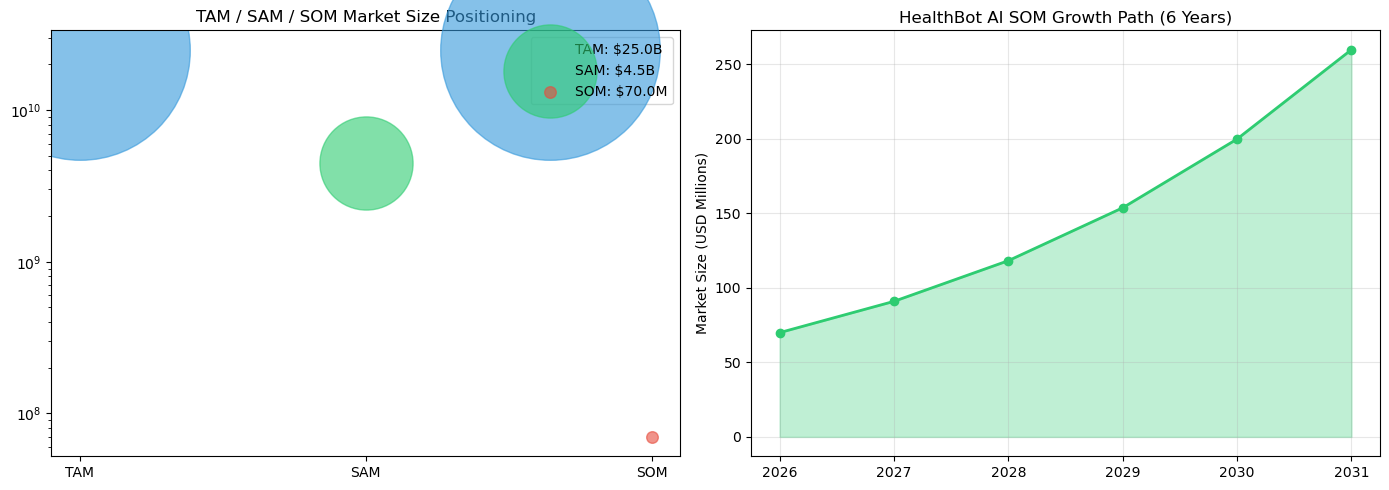

        🚀 HealthBot AI — Strategic Audit Overview        
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Business Parameter                   ┃ Assessed Metric ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ System Viability Index               │ 55.1/100        │
│ Total Addressable Market (TAM)       │ $25.0B          │
│ Serviceable Addressable Market (SAM) │ $4.5B           │
│ Serviceable Obtainable Market (SOM)  │ $70M            │
│ Mapped Competitive Threats           │ 5               │
│ Flagged Strategic Risk Vectors       │ 5               │
└──────────────────────────────────────┴─────────────────┘


📊 SWOT Analysis Highlights:
  STRENGTHS: High Accuracy & Trustworthiness: RAG on medical knowledge bases minimizes hallucinations and provides verifiable information, building user trust and differentiating from generic AI chatbots.
  WEAKNESSES: Data Security & Privacy Concerns: Handling sensitive medical data necessitates robust, HIPAA/GDPR-compliant infrastructure and processes, which are complex and costly for a seed-stage startup to establish and maintain.
  OPPORTUNITIES: Growing Demand for Personalized Digital Health Solutions: Increasing user adoption and need for remote monitoring, preventative care, and self-management tools create a fertile market for personalized health assistants.
  THREATS: Intense Competition from Established Tech Giants & Startups: Large tech companies (e.g., Google Health, Apple Health) and well-funded HealthTech startups possess significant resources, brand recognition, and existing user bases, making market penetration difficult.

💡 Top Actionable R

In [8]:
# ── Cell 5 | Verification Run Demo ─────────────────────────────────
sample = StartupProfile(
    name="HealthBot AI",
    description="AI-powered personal health assistant using RAG on medical knowledge bases",
    industry="HealthTech",
    stage="seed",
    target_market="Urban millennials 25-40 managing chronic conditions",
    revenue_model="SaaS subscription $29/month + B2B hospital licensing",
    team_size=4,
    funding_goal=1500000
)

analysis = advisor.analyze(sample)

print("\n📊 SWOT Analysis Highlights:")
for k, v in analysis.swot.items():
    print(f"  {k.upper()}: {v[0] if v else 'N/A'}")
    
print(f"\n💡 Top Actionable Recommendation: {analysis.recommendations[0] if analysis.recommendations else 'N/A'}")
print(f"\n📈 Year 1 Captured Revenue Projection: ${analysis.financial_proj.get('year1',0)/1000:.0f}K")
print(f"\n📣 Investor Pitch Deck Executive Preview:\n{analysis.pitch_deck[:400]}...")

# Gradio Web Application UI

In [9]:
# ── Cell 6 | Gradio Interactive App Interface ───────────────────────
import gradio as gr

def run_gradio_advisor(name, description, industry, stage, target_market, revenue_model, team_size, funding_goal):
    """Bridges Gradio inputs into the StartupAdvisorAgent engine"""
    profile = StartupProfile(
        name=name,
        description=description,
        industry=industry,
        stage=stage.lower(),
        target_market=target_market,
        revenue_model=revenue_model,
        team_size=int(team_size),
        funding_goal=float(funding_goal)
    )
    
    # Run full assessment pipeline
    analysis_res = advisor.analyze(profile)
    
    # 1. Format Markdown Scorecard
    scorecard_md = f"""
    ### 📊 Business Viability Assessment Scorecard
    * **Calculated Strategy Viability Rating:** `{analysis_res.score}/100`
    * **Estimated Industry Growth Baseline:** `{analysis_res.market_size.get("growth_rate_pct", 0)}% Y-o-Y`
    * **Runway Projection:** `{analysis_res.financial_proj.get("runway_months")} Months`
    * **Target Break-even Horizon:** `{analysis_res.financial_proj.get("break_even_months")} Months`
    
    #### 💰 3-Year Capitalization Scale:
    * **Year 1 Target ARR Revenue Capture:** `${analysis_res.financial_proj.get("year1", 0):,.2f}`
    * **Year 2 Target ARR Revenue Capture:** `${analysis_res.financial_proj.get("year2", 0):,.2f}`
    * **Year 3 Target ARR Revenue Capture:** `${analysis_res.financial_proj.get("year3", 0):,.2f}`
    """
    
    # 2. Compile SWOT Markdown Lists
    swot_data = analysis_res.swot
    swot_md = f"""
    ### 🔍 AI-Generated SWOT Audit Matrix
    * 💪 **Strengths:** {", ".join(swot_data.get("strengths", ["N/A"]))}
    * ⚠️ **Weaknesses:** {", ".join(swot_data.get("weaknesses", ["N/A"]))}
    * 📈 **Opportunities:** {", ".join(swot_data.get("opportunities", ["N/A"]))}
    * 🚨 **Threats:** {", ".join(swot_data.get("threats", ["N/A"]))}
    """
    
    # Path to saved matplotlib subplot
    chart_path = "output/market_analysis.png" if os.path.exists("output/market_analysis.png") else None
    
    return scorecard_md, swot_md, chart_path, analysis_res.pitch_deck

# ── Gradio Blocks Interface Layout Grid ──────────────────────────────
with gr.Blocks() as demo:
    gr.Markdown("# 🚀 AI Startup Advisor — Interactive Strategy Hub")
    gr.Markdown("Instantly compute TAM/SAM/SOM charts, compile automated SWOT matrices, evaluate financial horizons, and generate data-driven investor pitch decks.")
    
    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### 🛠️ Startup Corporate Settings")
            in_name = gr.Textbox(label="Startup Name", value="HealthBot AI")
            in_desc = gr.Textbox(label="Core Business Value Description", lines=3, value="AI-powered personal health assistant using RAG on medical knowledge bases")
            in_ind = gr.Dropdown(choices=["HealthTech", "FinTech", "SaaS", "E-Commerce", "EdTech", "CleanTech"], value="HealthTech", label="Industry Vertical")
            in_stage = gr.Dropdown(choices=["Idea", "Pre-Seed", "Seed", "Series-A"], value="Seed", label="Funding Stage")
            in_market = gr.Textbox(label="Target Market / Demographic Profile", value="Urban millennials 25-40 managing chronic conditions")
            in_rev = gr.Textbox(label="Revenue Stream Model Architecture", value="SaaS subscription $29/month + B2B hospital licensing")
            in_team = gr.Number(label="Core Team Size (Count)", value=4)
            in_fund = gr.Number(label="Target Capital Funding Ask ($ USD)", value=1500000)
            
            btn_audit = gr.Button("🚀 Generate Enterprise Strategic Review", variant="primary")
            
        with gr.Column(scale=1):
            out_score = gr.Markdown("### 📊 Viability Index Breakdown")
            out_swot = gr.Markdown("### 🔍 SWOT Operational Parameters")
            out_chart = gr.Image(label="Market Positioning Graphic Output")
            
    gr.Markdown("### 📣 Data-Driven Investor Pitch Deck Outline Blueprint")
    out_pitch = gr.Textbox(label="10-Slide Investor Deck Structure", lines=12)

    btn_audit.click(
        fn=run_gradio_advisor,
        inputs=[in_name, in_desc, in_ind, in_stage, in_market, in_rev, in_team, in_fund],
        outputs=[out_score, out_swot, out_chart, out_pitch]
    )

demo.launch(inline=True, share=False, theme=gr.themes.Soft())

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


─────────────────────────────────── 🚀 Launching Strategic Audit: HealthBot AI ────────────────────────────────────

C:\Users\HP\AppData\Local\Temp\ipykernel_11744\4152532158.py:91: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


        🚀 HealthBot AI — Strategic Audit Overview        
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Business Parameter                   ┃ Assessed Metric ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ System Viability Index               │ 62.0/100        │
│ Total Addressable Market (TAM)       │ $100.0B         │
│ Serviceable Addressable Market (SAM) │ $5.0B           │
│ Serviceable Obtainable Market (SOM)  │ $400M           │
│ Mapped Competitive Threats           │ 5               │
│ Flagged Strategic Risk Vectors       │ 5               │
└──────────────────────────────────────┴─────────────────┘